# RoadGuardian AI
## Notebook 03 — CNN Model Training (EfficientNetB0)

Objective: Train a CNN using Transfer Learning (EfficientNetB0) to classify road damage into 5 classes.

Input: Processed cropped images from Notebook 2.5
Output: Trained .keras model

In [2]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
output_path = "/kaggle/working/processed_dataset"
val_output_path = "/kaggle/working/processed_dataset_val"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 5

print("Train folder exists:", os.path.exists(output_path))
print("Val folder exists:", os.path.exists(val_output_path))

Train folder exists: False
Val folder exists: False


In [4]:
base_path = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT"

train_images = os.path.join(base_path, "train/images")
train_labels = os.path.join(base_path, "train/labels")
val_images = os.path.join(base_path, "val/images")
val_labels = os.path.join(base_path, "val/labels")

class_names = {
    0: "Longitudinal_Crack",
    1: "Transverse_Crack",
    2: "Alligator_Crack",
    3: "Pothole",
    4: "Repair_Other"
}

for folder in class_names.values():
    os.makedirs(os.path.join(output_path, folder), exist_ok=True)
    os.makedirs(os.path.join(val_output_path, folder), exist_ok=True)

print("Paths & Folders Ready")

Paths & Folders Ready


In [5]:
def load_yolo_labels(label_path):
    annotations = []
    with open(label_path, "r") as file:
        for line in file.readlines():
            data = line.strip().split()
            class_id = int(data[0])
            x_center, y_center, width, height = map(float, data[1:5])
            annotations.append([class_id, x_center, y_center, width, height])
    return annotations

def convert_yolo_bbox(annotation, img_width, img_height):
    class_id, x, y, w, h = annotation
    x *= img_width; y *= img_height
    w *= img_width; h *= img_height
    x1 = int(x - w/2); y1 = int(y - h/2)
    x2 = int(x + w/2); y2 = int(y + h/2)
    return class_id, x1, y1, x2, y2

def crop_damage_region(image, annotation):
    height, width = image.shape[:2]
    class_id, x1, y1, x2, y2 = convert_yolo_bbox(annotation, width, height)
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(width, x2); y2 = min(height, y2)
    crop = image[y1:y2, x1:x2]
    return class_id, crop

def resize_crop(image):
    return cv2.resize(image, (IMG_SIZE, IMG_SIZE))

def save_processed_image(image, class_id, index, base_path):
    folder = os.path.join(base_path, class_names[class_id])
    file_path = os.path.join(folder, f"damage_{index}.jpg")
    cv2.imwrite(file_path, image)

print("Functions Ready")

Functions Ready


In [6]:
image_counter = 0
for image_name in tqdm(os.listdir(train_images)):
    if image_name.endswith(".jpg"):
        img_path = os.path.join(train_images, image_name)
        label_path = os.path.join(train_labels, image_name.replace(".jpg", ".txt"))
        if os.path.exists(label_path):
            image = cv2.imread(img_path)
            labels = load_yolo_labels(label_path)
            for label in labels:
                class_id, crop = crop_damage_region(image, label)
                if crop.size != 0:
                    crop = resize_crop(crop)
                    save_processed_image(crop, class_id, image_counter, output_path)
                    image_counter += 1
print("Train Done:", image_counter)

100%|██████████| 26869/26869 [12:04<00:00, 37.09it/s]

Train Done: 46295


In [7]:
val_image_counter = 0
for image_name in tqdm(os.listdir(val_images)):
    if image_name.endswith(".jpg"):
        img_path = os.path.join(val_images, image_name)
        label_path = os.path.join(val_labels, image_name.replace(".jpg", ".txt"))
        if os.path.exists(label_path):
            image = cv2.imread(img_path)
            labels = load_yolo_labels(label_path)
            for label in labels:
                class_id, crop = crop_damage_region(image, label)
                if crop.size != 0:
                    crop = resize_crop(crop)
                    save_processed_image(crop, class_id, val_image_counter, val_output_path)
                    val_image_counter += 1
print("Val Done:", val_image_counter)

100%|██████████| 5758/5758 [02:31<00:00, 37.95it/s]

Val Done: 9741


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True, seed=42
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_output_path, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False
)
class_labels = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
print("Classes:", class_labels)

Found 46295 files belonging to 5 classes.


I0000 00:00:1785701765.589202      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785701765.595122      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 9741 files belonging to 5 classes.
Classes: ['Alligator_Crack', 'Longitudinal_Crack', 'Pothole', 'Repair_Other', 'Transverse_Crack']


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
])

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ModelCheckpoint('best_model_phase1.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]
history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks, verbose=2)

Epoch 1/20


E0000 00:00:1785701918.858471      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2894/2894 - 156s - 54ms/step - accuracy: 0.7678 - loss: 0.6426 - val_accuracy: 0.8136 - val_loss: 0.5312 - learning_rate: 0.0010
Epoch 2/20
2894/2894 - 140s - 48ms/step - accuracy: 0.8002 - loss: 0.5594 - val_accuracy: 0.8317 - val_loss: 0.4862 - learning_rate: 0.0010
Epoch 3/20
2894/2894 - 140s - 48ms/step - accuracy: 0.8091 - loss: 0.5369 - val_accuracy: 0.8397 - val_loss: 0.4694 - learning_rate: 0.0010
Epoch 4/20
2894/2894 - 140s - 48ms/step - accuracy: 0.8157 - loss: 0.5215 - val_accuracy: 0.8450 - val_loss: 0.4512 - learning_rate: 0.0010
Epoch 5/20
2894/2894 - 139s - 48ms/step - accuracy: 0.8208 - loss: 0.5087 - val_accuracy: 0.8446 - val_loss: 0.4578 - learning_rate: 0.0010
Epoch 6/20
2894/2894 - 140s - 48ms/step - accuracy: 0.8252 - loss: 0.4992 - val_accuracy: 0.8459 - val_loss: 0.4542 - learning_rate: 0.0010
Epoch 7/20
2894/2894 - 140s - 49ms/step - accuracy: 0.8264 - loss: 0.4880 - val_accuracy: 0.8531 - val_loss: 0.4346 - learning_rate: 0.0010
Epoch 8/20
2894/2894 - 140s - 4

In [12]:
import os
print(os.listdir("/kaggle/working"))

['best_model_phase1.keras', 'processed_dataset', '.virtual_documents', 'processed_dataset_val']


In [13]:
model = tf.keras.models.load_model('/kaggle/working/best_model_phase1.keras')
print("Phase 1 Best Model Loaded Successfully")
model.summary()

Phase 1 Best Model Loaded Successfully


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,543,412 (17.33 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 329,228 (1.26 MB)

In [14]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_ft = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ModelCheckpoint('best_model_final.keras', save_best_only=True, monitor='val_accuracy'),
]
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks_ft, verbose=2)

Epoch 1/15


E0000 00:00:1785706162.754232      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2894/2894 - 152s - 53ms/step - accuracy: 0.8399 - loss: 0.4528 - val_accuracy: 0.8635 - val_loss: 0.4063
Epoch 2/15
2894/2894 - 140s - 49ms/step - accuracy: 0.8421 - loss: 0.4469 - val_accuracy: 0.8654 - val_loss: 0.4020
Epoch 3/15
2894/2894 - 141s - 49ms/step - accuracy: 0.8437 - loss: 0.4436 - val_accuracy: 0.8656 - val_loss: 0.3999
Epoch 4/15
2894/2894 - 140s - 48ms/step - accuracy: 0.8459 - loss: 0.4390 - val_accuracy: 0.8662 - val_loss: 0.3983
Epoch 5/15
2894/2894 - 140s - 48ms/step - accuracy: 0.8458 - loss: 0.4386 - val_accuracy: 0.8655 - val_loss: 0.3979
Epoch 6/15
2894/2894 - 140s - 48ms/step - accuracy: 0.8448 - loss: 0.4371 - val_accuracy: 0.8654 - val_loss: 0.3971
Epoch 7/15
2894/2894 - 140s - 48ms/step - accuracy: 0.8459 - loss: 0.4359 - val_accuracy: 0.8655 - val_loss: 0.3965
Epoch 8/15
2894/2894 - 140s - 48ms/step - accuracy: 0.8484 - loss: 0.4335 - val_accuracy: 0.8656 - val_loss: 0.3957
Epoch 9/15
2894/2894 - 139s - 48ms/step - accuracy: 0.8446 - loss: 0.4367 - val_acc

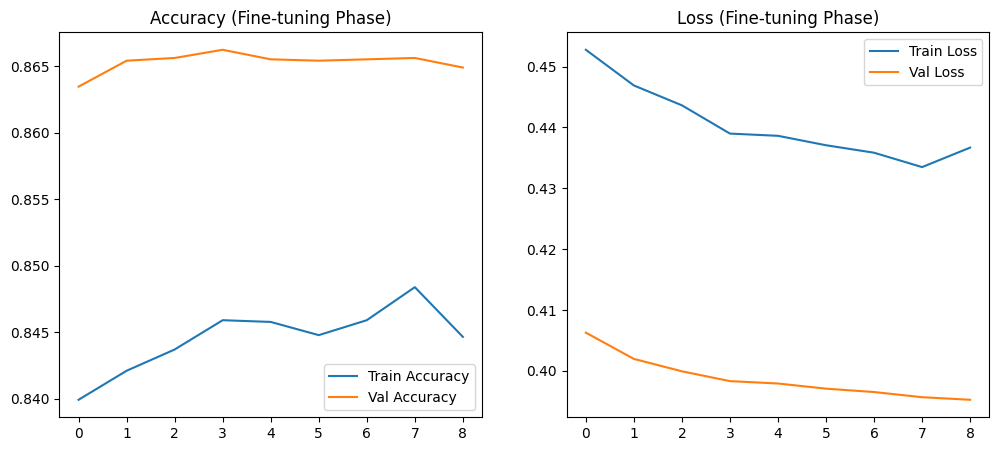

In [15]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy (Fine-tuning Phase)')

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss (Fine-tuning Phase)')

plt.show()

In [17]:
model.save('/kaggle/working/roadguardian_model.keras')
print("Model Saved Successfully")

Model Saved Successfully


In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("Predictions Complete")

Predictions Complete


In [21]:
print(classification_report(y_true, y_pred, target_names=class_labels))

                    precision    recall  f1-score   support

   Alligator_Crack       0.86      0.71      0.78      1553
Longitudinal_Crack       0.86      0.92      0.89      3890
           Pothole       0.89      0.86      0.87      1564
      Repair_Other       0.80      0.79      0.79       965
  Transverse_Crack       0.91      0.93      0.92      1769

          accuracy                           0.87      9741
         macro avg       0.86      0.84      0.85      9741
      weighted avg       0.87      0.87      0.86      9741



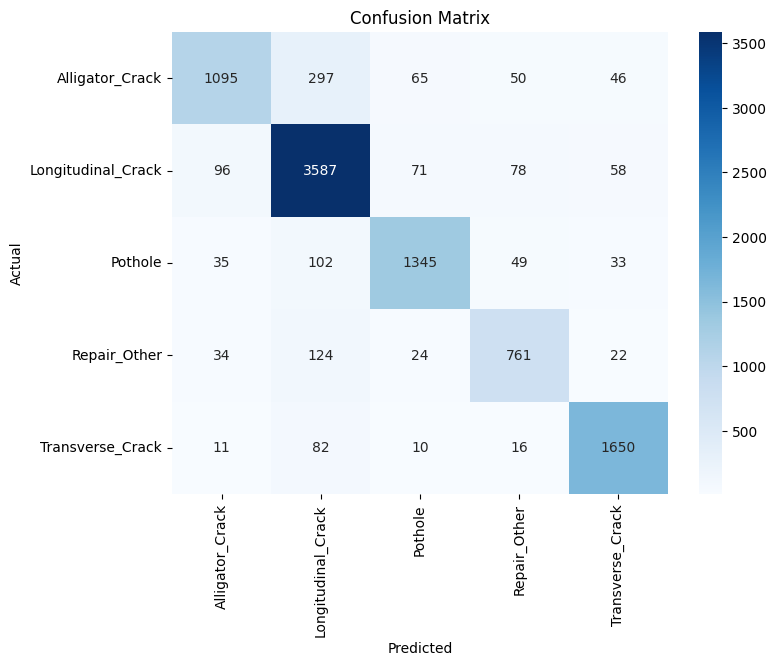

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

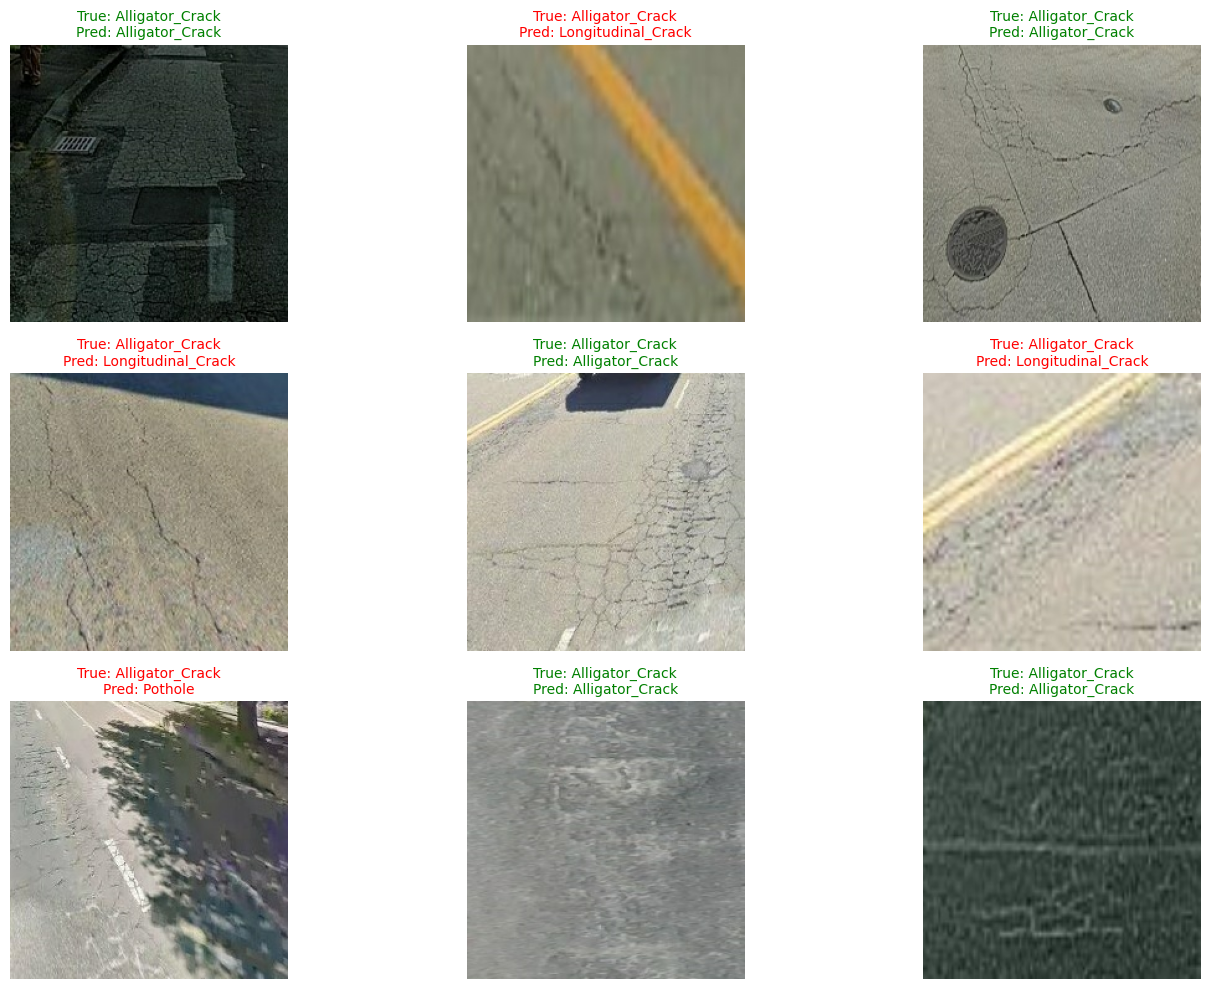

In [23]:
 plt.figure(figsize=(15, 10))

for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_labels[np.argmax(labels[i])]
        pred_label = class_labels[np.argmax(preds[i])]
        color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis("off")
    break

plt.tight_layout()
plt.show()